# Etapa 1 — Entendimento e Preparação
## EDA + ML Canvas + Baselines — Tech Challenge: Previsão de Churn

**Objetivo desta etapa:** entender o problema de negócio, explorar os dados
em profundidade, e estabelecer baselines simples (Dummy + Regressão
Logística) registrados no MLflow, antes de avançar para a rede neural
(Etapa 2).

Este notebook é **exploratório**: a lógica de produção (limpeza, pipeline,
modelos) vive em `src/churn_prediction/`, e este notebook a importa e a usa,
em vez de duplicar código — assim o notebook nunca fica fora de sincronia
com o pacote.


## 1. ML Canvas

| Bloco | Descrição |
|---|---|
| **Problema de negócio** | A operadora está perdendo clientes (churn) em ritmo acelerado. A diretoria precisa identificar, com antecedência, quais clientes têm maior risco de cancelar para agir preventivamente (ofertas de retenção, contato proativo). |
| **Stakeholders** | Diretoria comercial (decisão estratégica), time de retenção/CRM (executa as ações), time de Engenharia de Dados/ML (constrói e mantém o modelo), clientes finais (impactados indiretamente pelas ações de retenção). |
| **Pergunta de ML** | Dado o perfil contratual, demográfico e de uso de um cliente, qual a probabilidade de ele cancelar o serviço (churn) no próximo ciclo? |
| **Fonte e tipo de dados** | Dataset tabular público IBM/Kaggle *Telco Customer Churn* — 7.043 clientes, 21 colunas (demografia, serviços contratados, conta, churn). Dados estáticos (snapshot), não temporais/streaming. |
| **Métrica técnica (offline)** | **ROC-AUC** como métrica primária (robusta a desbalanceamento moderado); **PR-AUC**, **F1**, **Precision** e **Recall** como métricas de apoio, dado que a classe positiva (churn) é minoritária (~26,5%). |
| **Métrica de negócio** | **Custo esperado** = `FP × custo_ação_retenção + FN × custo_perda_cliente`. Assume-se `custo_ação_retenção ≈ R$30` (desconto/contato) e `custo_perda_cliente ≈ R$800` (≈12 meses de receita média perdida). Ver `docs/model_card.md` para a discussão completa dessas premissas. |
| **Baseline mínimo aceitável** | Superar a Regressão Logística (interpretável, rápida de treinar) em ROC-AUC e em custo esperado de negócio. |
| **SLO de serving** | Latência p95 < 200ms por predição individual via API; disponibilidade alvo 99% (ambiente de demonstração/portfólio, não SLA de produção real). |
| **Riscos e vieses conhecidos** | Dataset sintético/anonimizado (não reflete eventuais sazonalidades reais); possível viés socioeconômico embutido em variáveis como `PaymentMethod`; ver Model Card para análise de subgrupos. |
| **Janela de decisão / ação** | Mensal: o modelo é re-rodado a cada ciclo de faturamento, gerando uma lista de clientes de risco para o time de retenção agir antes do próximo boleto. |


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn_prediction.data.loader import load_raw_data, clean_data
from churn_prediction.config import RANDOM_SEED

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(RANDOM_SEED)


## 2. Carregamento dos dados e inventário inicial

Carregamos os dados brutos (sem nenhuma transformação) e fazemos um
inventário de volume, tipos e qualidade.


In [2]:
df_raw = load_raw_data("../data/raw/Telco-Customer-Churn.csv")
print(f"Shape: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
df_raw.head()


{"timestamp": "2026-06-29T21:55:11.095721+00:00", "level": "INFO", "logger": "churn_prediction.data.loader", "message": "loading_raw_data", "path": "../data/raw/Telco-Customer-Churn.csv"}


{"timestamp": "2026-06-29T21:55:11.169997+00:00", "level": "INFO", "logger": "churn_prediction.data.loader", "message": "raw_data_loaded", "n_rows": 7043, "n_cols": 21}


Shape: 7043 linhas x 21 colunas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Volume: bem acima do mínimo exigido (>= 5.000 registros, >= 10 features)
print(f"Registros: {len(df_raw)}")
print(f"Features (excluindo ID e target): {df_raw.shape[1] - 2}")


Registros: 7043
Features (excluindo ID e target): 19


## 3. Qualidade de dados (Data Readiness)

Pontos identificados nesta etapa:
1. `TotalCharges` está tipado como `object` (string), não `float`.
2. Não há valores `NaN` explícitos, mas pode haver strings vazias.
3. Verificamos duplicados em `customerID`.


In [5]:
print("Tipos de dados originais:")
print(df_raw.dtypes)
print()
print("Valores nulos (NaN) por coluna:")
print(df_raw.isnull().sum().sum(), "valores nulos no total")


Tipos de dados originais:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Valores nulos (NaN) por coluna:
0 valores nulos no total


In [6]:
# TotalCharges: investigação do problema de tipo
blank_total_charges = df_raw[df_raw["TotalCharges"].astype(str).str.strip() == ""]
print(f"Linhas com TotalCharges em branco: {len(blank_total_charges)}")
blank_total_charges[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]


Linhas com TotalCharges em branco: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [7]:
# Confirmação: todos os blanks correspondem a clientes com tenure == 0
# (clientes novíssimos, ainda não cobrados) -> decisão de negócio: TotalCharges = 0.0
assert (blank_total_charges["tenure"] == 0).all(), "Hipótese refutada!"
print("Confirmado: 100% dos TotalCharges em branco correspondem a tenure == 0.")
print("Decisão: tratar como 0.0 (não como dado ausente/MAR/MCAR).")


Confirmado: 100% dos TotalCharges em branco correspondem a tenure == 0.
Decisão: tratar como 0.0 (não como dado ausente/MAR/MCAR).


In [8]:
# Duplicados
print("customerID duplicados:", df_raw["customerID"].duplicated().sum())
print("Linhas 100% duplicadas:", df_raw.duplicated().sum())


customerID duplicados: 0
Linhas 100% duplicadas: 0


In [9]:
# Aplicamos a limpeza oficial do pacote (mesma usada em produção)
df = clean_data(df_raw)
df[["TotalCharges", "Churn"]].dtypes


{"timestamp": "2026-06-29T21:55:11.272923+00:00", "level": "INFO", "logger": "churn_prediction.data.loader", "message": "filling_blank_total_charges", "n_blank": 11}


{"timestamp": "2026-06-29T21:55:11.277073+00:00", "level": "INFO", "logger": "churn_prediction.data.loader", "message": "data_cleaned", "n_rows_before": 7043, "n_rows_after": 7043}


TotalCharges    float64
Churn             int64
dtype: object

## 4. Distribuição da variável target (Churn)

O problema é de classificação binária com **desbalanceamento moderado**
(não severo) — a classe positiva (churn) representa ~26,5% da base.
Isso justifica o uso de `class_weight="balanced"` nos baselines e
`pos_weight` na loss da rede neural, em vez de oversampling agressivo
(que poderia distorcer a distribuição real do problema de negócio).


/tmp/ipykernel_597/2429735988.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Não Churn (0)", "Churn (1)"])


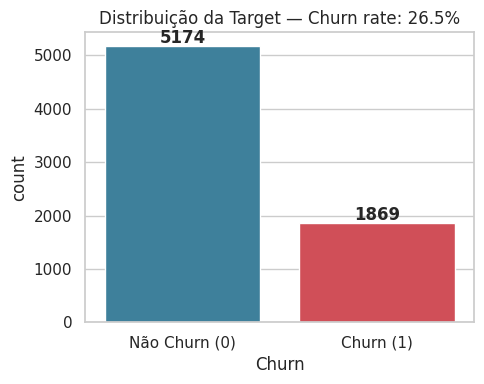

Churn rate global: 26.54%
Razão de desbalanceamento (neg:pos): 2.77:1


In [10]:
churn_counts = df["Churn"].value_counts()
churn_rate = df["Churn"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Churn", hue="Churn", palette=["#2E86AB", "#E63946"], legend=False, ax=ax)
ax.set_xticklabels(["Não Churn (0)", "Churn (1)"])
ax.set_title(f"Distribuição da Target — Churn rate: {churn_rate:.1%}")
for i, v in enumerate(churn_counts.sort_index()):
    ax.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Churn rate global: {churn_rate:.2%}")
print(f"Razão de desbalanceamento (neg:pos): {(1-churn_rate)/churn_rate:.2f}:1")


## 5. Variáveis numéricas: distribuição e relação com churn

Analisamos `tenure` (meses como cliente), `MonthlyCharges` e `TotalCharges`.


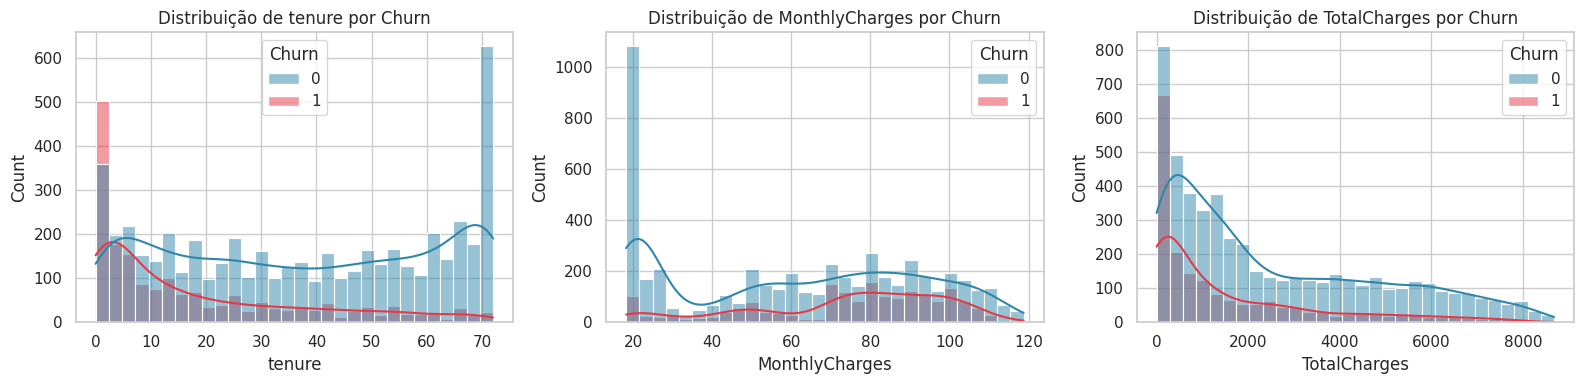

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"], strict=True):
    sns.histplot(data=df, x=col, hue="Churn", bins=30, kde=True, ax=ax, palette=["#2E86AB", "#E63946"])
    ax.set_title(f"Distribuição de {col} por Churn")
plt.tight_layout()
plt.show()


In [12]:
print("Correlação (point-biserial via Pearson) das numéricas com Churn:")
print(df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()["Churn"].sort_values())


Correlação (point-biserial via Pearson) das numéricas com Churn:
tenure           -0.352229
TotalCharges     -0.198324
MonthlyCharges    0.193356
Churn             1.000000
Name: Churn, dtype: float64


**Leitura:** `tenure` tem a correlação mais forte (negativa) com churn —
clientes mais antigos cancelam menos, um padrão esperado e intuitivo
(quanto mais tempo o cliente já investiu na relação, menor a propensão a
trocar de operadora). `MonthlyCharges` tem correlação positiva: cobranças
mensais mais altas associam-se a mais churn.


## 6. Variáveis categóricas: os maiores sinais de risco

Olhamos a taxa de churn dentro de cada categoria das variáveis mais
relevantes ao negócio: tipo de contrato, serviço de internet e forma
de pagamento.


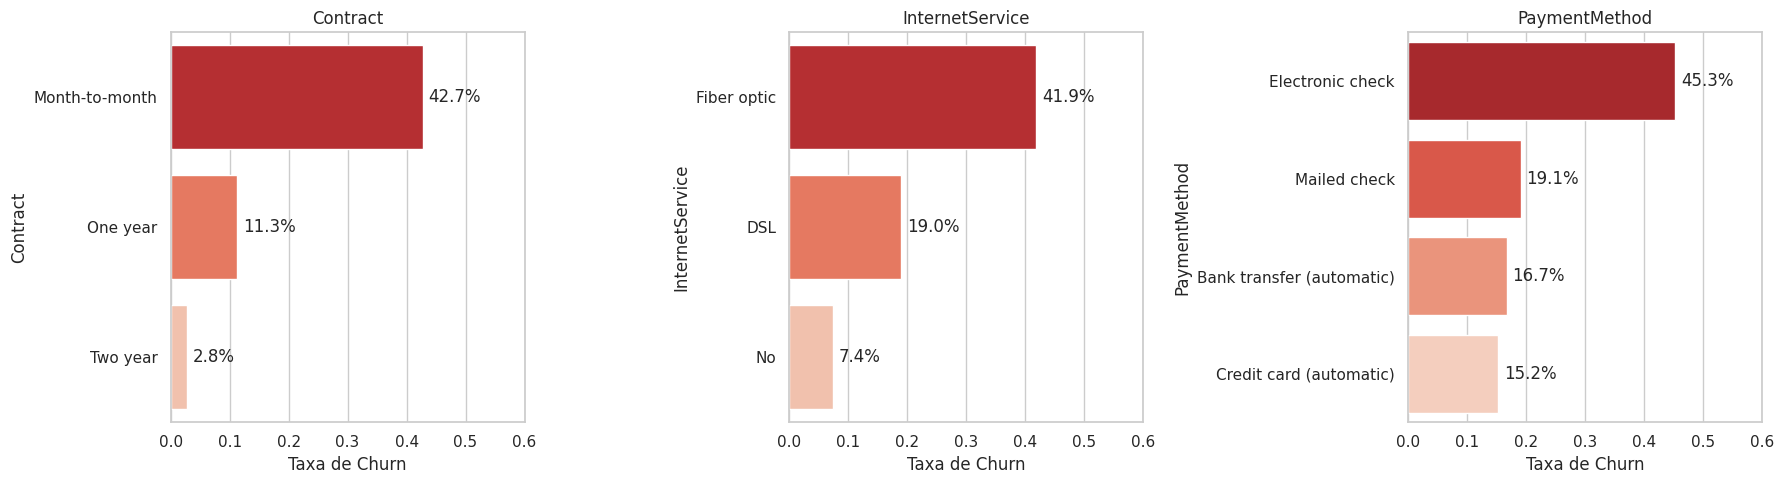

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(
    axes, ["Contract", "InternetService", "PaymentMethod"], strict=True
):
    rates = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="Reds_r", hue=rates.index, legend=False)
    ax.set_xlabel("Taxa de Churn")
    ax.set_title(col)
    ax.set_xlim(0, 0.6)
    for i, v in enumerate(rates.values):
        ax.text(v + 0.01, i, f"{v:.1%}", va="center")

plt.tight_layout()
plt.show()


**Leitura de negócio — os 3 sinais de risco mais fortes:**

1. **Contrato Month-to-month**: ~42,7% de churn, vs. 11,3% (1 ano) e 2,8%
   (2 anos). O tipo de contrato é, isoladamente, o sinal mais forte do
   dataset — faz sentido, pois contratos de longo prazo têm barreira de
   saída (multas, planejamento).
2. **Internet via Fibra Ótica**: ~41,9% de churn, quase o dobro de DSL
   (~19,0%). Hipótese a investigar com o negócio: problema de
   precificação, qualidade percebida ou concorrência mais forte nesse
   segmento.
3. **Pagamento via Electronic Check**: ~45,3% de churn, bem acima dos
   métodos automáticos (~15-19%). Pagamento manual pode ser proxy de
   menor "fricção de saída" ou de um perfil de cliente menos fidelizado.


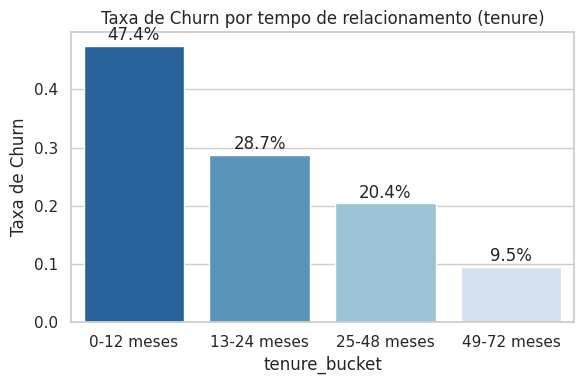

In [14]:
# tenure_bucket: visualizar o efeito de "tempo de relacionamento"
df["tenure_bucket"] = pd.cut(
    df["tenure"], bins=[-1, 12, 24, 48, 72],
    labels=["0-12 meses", "13-24 meses", "25-48 meses", "49-72 meses"],
)
tenure_churn = df.groupby("tenure_bucket", observed=True)["Churn"].mean()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=tenure_churn.index, y=tenure_churn.values, hue=tenure_churn.index, palette="Blues_r", legend=False, ax=ax)
ax.set_ylabel("Taxa de Churn")
ax.set_title("Taxa de Churn por tempo de relacionamento (tenure)")
for i, v in enumerate(tenure_churn.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()


Confirma o padrão: a taxa de churn cai de forma quase monotônica
conforme o tempo de relacionamento aumenta (47,4% nos primeiros 12 meses
contra apenas 9,5% após 49 meses). Isso é coerente com o sinal de
correlação observado para `tenure`.


## 7. Matriz de correlação completa (features numéricas + dummies binárias)


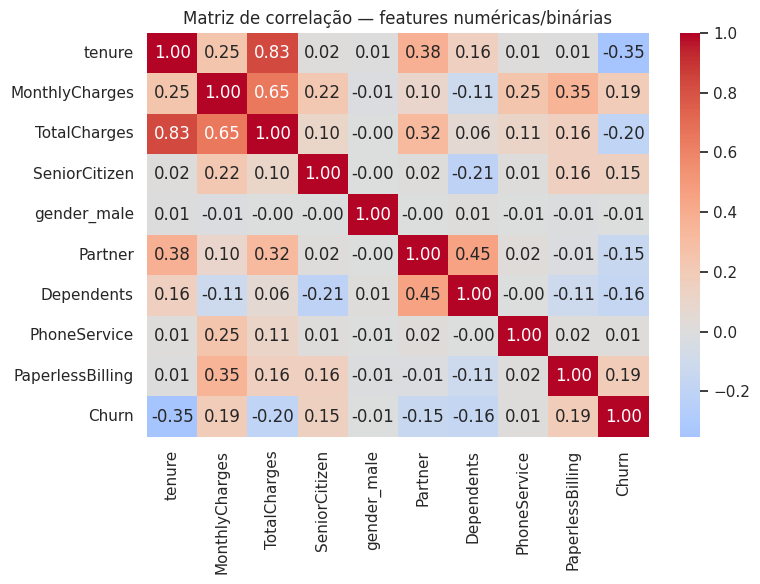

In [15]:
binary_map_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
df_corr = df.copy()
for c in binary_map_cols:
    df_corr[c] = df_corr[c].map({"Yes": 1, "No": 0})
df_corr["gender_male"] = (df_corr["gender"] == "Male").astype(int)
df_corr["SeniorCitizen"] = df_corr["SeniorCitizen"].astype(int)

corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen",
             "gender_male", *binary_map_cols, "Churn"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_corr[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlação — features numéricas/binárias")
plt.tight_layout()
plt.show()


## 8. Data Readiness — resumo executivo

| Critério | Situação | Ação tomada |
|---|---|---|
| Volume | 7.043 registros, 19 features preditivas | Acima do mínimo exigido (≥5.000 / ≥10) |
| Valores ausentes | 11 strings vazias em `TotalCharges` (0,16% das linhas) | Tratado como 0.0 (clientes com `tenure=0`) em `clean_data()` |
| Duplicados | 0 `customerID` duplicados | Nenhuma ação necessária (checagem defensiva mantida no código) |
| Tipos incorretos | `TotalCharges` como string | Conversão para `float` em `clean_data()` |
| Desbalanceamento | 73,5% / 26,5% (moderado) | `class_weight="balanced"` (sklearn) / `pos_weight` (PyTorch); métrica primária = ROC-AUC |
| Cardinalidade categórica | Todas as categóricas com ≤4 categorias | One-Hot Encoding é viável sem explosão dimensional |

**Conclusão:** os dados estão prontos para modelagem após a limpeza leve
documentada acima. Toda a lógica de limpeza está implementada e testada em
`src/churn_prediction/data/loader.py` (ver `tests/test_schema.py`).


## 9. Baselines (Scikit-Learn) + Registro no MLflow

Treinamos três baselines, do mais simples ao mais sofisticado:

1. **DummyClassifier** (`most_frequent`): piso de performance — qualquer
   modelo real deve superá-lo com folga.
2. **Regressão Logística**: baseline linear, rápido e interpretável.
3. **Random Forest**: baseline não-linear, para servir de "régua" mais
   forte antes de justificarmos a complexidade adicional do MLP.

Cada baseline é avaliado com **validação cruzada estratificada (5-fold)**
no conjunto de treino e, depois, no conjunto de teste hold-out — replicando
exatamente o que `src/churn_prediction/train.py` faz em produção.


In [16]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
import mlflow

from churn_prediction.config import ALL_FEATURES, MLFLOW_CONFIG, TEST_SIZE
from churn_prediction.models.baselines import BASELINE_BUILDERS
from churn_prediction.models.metrics import evaluate_predictions

X = df[ALL_FEATURES]
y = df["Churn"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
)
print(f"Treino: {len(X_train)} | Teste: {len(X_test)}")
print(f"Churn rate treino: {y_train.mean():.2%} | Churn rate teste: {y_test.mean():.2%}")


Treino: 5634 | Teste: 1409
Churn rate treino: 26.54% | Churn rate teste: 26.54%


In [17]:
mlflow.set_tracking_uri(MLFLOW_CONFIG.tracking_uri)
mlflow.set_experiment(MLFLOW_CONFIG.experiment_name)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
results = {}

for name, builder in BASELINE_BUILDERS.items():
    with mlflow.start_run(run_name=f"eda_notebook_{name}"):
        mlflow.log_param("model_type", name)
        mlflow.log_param("source", "01_eda_and_baselines.ipynb")

        pipe = builder()
        cv_scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="roc_auc")
        mlflow.log_metric("cv_roc_auc_mean", float(cv_scores.mean()))
        mlflow.log_metric("cv_roc_auc_std", float(cv_scores.std()))

        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_test)[:, 1]
        result = evaluate_predictions(y_test, proba)
        for metric_name, value in result.to_dict().items():
            mlflow.log_metric(f"test_{metric_name}", value)

        results[name] = {"cv_roc_auc_mean": cv_scores.mean(), **result.to_dict()}
        print(f"{name}: CV ROC-AUC={cv_scores.mean():.4f} | Test ROC-AUC={result.roc_auc:.4f} | "
              f"F1={result.f1:.4f} | Custo={result.business_cost:.0f}")


dummy_most_frequent: CV ROC-AUC=0.5000 | Test ROC-AUC=0.5000 | F1=0.0000 | Custo=299200


logistic_regression: CV ROC-AUC=0.8460 | Test ROC-AUC=0.8415 | F1=0.6136 | Custo=73440


random_forest: CV ROC-AUC=0.8468 | Test ROC-AUC=0.8424 | F1=0.6242 | Custo=79560


In [18]:
comparison_df = pd.DataFrame(results).T
comparison_df[["cv_roc_auc_mean", "roc_auc", "pr_auc", "f1", "precision", "recall", "business_cost"]].round(4)


,cv_roc_auc_mean,roc_auc,pr_auc,f1,precision,recall,business_cost
dummy_most_frequent,0.5000,0.5000,0.2654,0.0000,0.0000,0.0000,299200.0
logistic_regression,0.8460,0.8415,0.6329,0.6136,0.5043,0.7834,73440.0
random_forest,0.8468,0.8424,0.6569,0.6242,0.5299,0.7594,79560.0


## 10. Conclusões da Etapa 1

- O dataset está limpo, balanceado o suficiente para ser tratado com
  `class_weight`/`pos_weight` (sem necessidade de SMOTE), e com volume e
  cardinalidade adequados para uma rede neural simples.
- Os 3 sinais de negócio mais fortes — **tipo de contrato**, **tipo de
  internet** e **forma de pagamento** — já direcionam ações de retenção
  óbvias (ex.: incentivar migração para contratos anuais).
- A Regressão Logística e o Random Forest já alcançam ROC-AUC ~0.84,
  estabelecendo a régua que o MLP (Etapa 2) precisa pelo menos igualar,
  idealmente superando-os na métrica de **custo de negócio**, que é o que
  realmente importa para a diretoria.
- Todos os experimentos desta etapa estão registrados no MLflow
  (`experiment: churn-prediction`), prontos para comparação com o MLP na
  Etapa 2 (ver `notebooks/02_mlp_and_comparison.ipynb` e
  `src/churn_prediction/train.py`).
